# Step 1: Select Features and Target

In [20]:
import pandas as pd

master_df = pd.read_csv(
    '../data/processed/stock_features.csv'
)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company,Daily_Return,MA_7,MA_21,...,Price_vs_MA21,Price_vs_MA50,Rolling_Std_7,Rolling_Std_21,Vol_Ratio,Volume_MA7,Volume_Ratio,Range_Pct,Open_Close_Pct,Target
0,2019-03-13,514.306824,516.027675,501.729527,502.399370,57166348,HDFC_Bank,0.025587,494.712450,488.937199,...,1.051887,1.053837,10.000527,7.742725,1.291603,1.700591e+07,3.361557,0.027801,0.023701,513.891113
1,2019-03-14,513.891113,519.146096,510.622652,518.534000,15379864,HDFC_Bank,-0.000808,498.594696,489.873250,...,1.049029,1.052222,11.535659,9.421351,1.224417,1.751200e+07,0.878247,0.016586,-0.008954,520.416565
2,2019-03-15,520.416565,522.010361,514.653419,515.334823,12763088,HDFC_Bank,0.012698,503.503213,491.229482,...,1.059416,1.064330,12.574926,11.543940,1.089310,1.812700e+07,0.704093,0.014137,0.009861,522.368347
3,2019-03-18,522.368347,529.344181,519.030578,522.472281,14358720,HDFC_Bank,0.003750,507.956342,492.893146,...,1.059800,1.066813,13.002543,13.346031,0.974263,1.872041e+07,0.767009,0.019744,-0.000199,523.823547
4,2019-03-19,523.823547,525.706079,519.954495,524.227777,11957992,HDFC_Bank,0.002786,512.561244,494.731152,...,1.058804,1.068270,11.901308,14.814323,0.803365,1.942106e+07,0.615723,0.010980,-0.000771,531.041931


In [21]:
master_df['Date'] = pd.to_datetime(master_df['Date'])

In [22]:
print(master_df['Date'].min())
print(master_df['Date'].max())

2019-03-13 00:00:00
2025-12-29 00:00:00


# Step 1:TRAIN AND TEST SPLIT

In [23]:
train_df = master_df[
    master_df['Date'] < '2025-01-01'
]

test_df = master_df[
    master_df['Date'] >= '2025-01-01'
]

In [24]:
print(train_df.shape)
print(test_df.shape)

(8592, 27)
(1482, 27)


In [25]:
feature_cols = [

    # Price Features
    'Open',
    'High',
    'Low',
    'Close',

    # Volume Features
    'Volume',
    'Volume_MA7',
    'Volume_Ratio',

    # Trend Features
    'MA_7',
    'MA_21',
    'MA_50',

    # Lag Features
    'Lag_1',
    'Lag_5',
    'Lag_10',

    # Return Features
    'Daily_Return',
    'Momentum_5',
    'Momentum_21',

    # Relative Price Features
    'Price_vs_MA7',
    'Price_vs_MA21',
    'Price_vs_MA50',

    # Volatility Features
    'Rolling_Std_7',
    'Rolling_Std_21',
    'Vol_Ratio',

    # Candlestick Features
    'Range_Pct',
    'Open_Close_Pct'
]

In [26]:
X_train = train_df[feature_cols]
y_train = train_df['Target']

X_test = test_df[feature_cols]
y_test = test_df['Target']

In [27]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Data Shape: (8592, 24)
Testing Data Shape: (1482, 24)
Training Target Shape: (8592,)
Testing Target Shape: (1482,)


In [28]:
X_train.head()

,Open,High,Low,Close,Volume,Volume_MA7,Volume_Ratio,MA_7,MA_21,MA_50,...,Momentum_5,Momentum_21,Price_vs_MA7,Price_vs_MA21,Price_vs_MA50,Rolling_Std_7,Rolling_Std_21,Vol_Ratio,Range_Pct,Open_Close_Pct
0,502.399370,516.027675,501.729527,514.306824,57166348,1.700591e+07,3.361557,494.712450,488.937199,488.032414,...,0.058121,0.048948,1.039608,1.051887,1.053837,10.000527,7.742725,1.291603,0.027801,0.023701
1,518.534000,519.146096,510.622652,513.891113,15379864,1.751200e+07,0.878247,498.594696,489.873250,488.386519,...,0.046203,0.039773,1.030679,1.049029,1.052222,11.535659,9.421351,1.224417,0.016586,-0.008954
2,515.334823,522.010361,514.653419,520.416565,12763088,1.812700e+07,0.704093,503.503213,491.229482,488.961680,...,0.058641,0.057896,1.033591,1.059416,1.064330,12.574926,11.543940,1.089310,0.014137,0.009861
3,522.472281,529.344181,519.030578,522.368347,14358720,1.872041e+07,0.767009,507.956342,492.893146,489.653027,...,0.062487,0.071676,1.028373,1.059800,1.066813,13.002543,13.346031,0.974263,0.019744,-0.000199
4,524.227777,525.706079,519.954495,523.823547,11957992,1.942106e+07,0.615723,512.561244,494.731152,490.347377,...,0.044565,0.079547,1.021973,1.058804,1.068270,11.901308,14.814323,0.803365,0.010980,-0.000771


In [29]:
len(feature_cols)

24

In [30]:
print(feature_cols)

['Open', 'High', 'Low', 'Close', 'Volume', 'Volume_MA7', 'Volume_Ratio', 'MA_7', 'MA_21', 'MA_50', 'Lag_1', 'Lag_5', 'Lag_10', 'Daily_Return', 'Momentum_5', 'Momentum_21', 'Price_vs_MA7', 'Price_vs_MA21', 'Price_vs_MA50', 'Rolling_Std_7', 'Rolling_Std_21', 'Vol_Ratio', 'Range_Pct', 'Open_Close_Pct']


In [31]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


# Step 3:Linear Regression

1.Train Model

In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


2.Make Predictions

In [33]:
y_pred = lr.predict(X_test)

y_pred[:5]

array([866.43674825, 870.86617858, 849.28597353, 832.03839607,
       832.8846369 ])

3.Evaluate Model

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)

MAE : 27.887533943257548
RMSE: 70.94166477060466
R² : 0.9997755331083293
Intercept: 161.19363488530962
Coefficients: [-1.31779940e-01 -5.93438318e-02  1.92134491e-02  1.07391933e+00
 -2.30376685e-08 -1.89871840e-08 -4.44491926e-01 -1.09395045e-01
  7.33278376e-02 -1.01383184e-02  1.17091130e-01  5.69907569e-02
 -2.82654968e-02  1.11470363e+02  9.00667675e+01  2.64246399e+01
 -1.29867504e+02 -1.89058514e+01 -1.34044477e+01 -5.89295863e-04
 -1.65689457e-02  1.83814299e+00  6.06509161e+01 -1.32633264e+02]


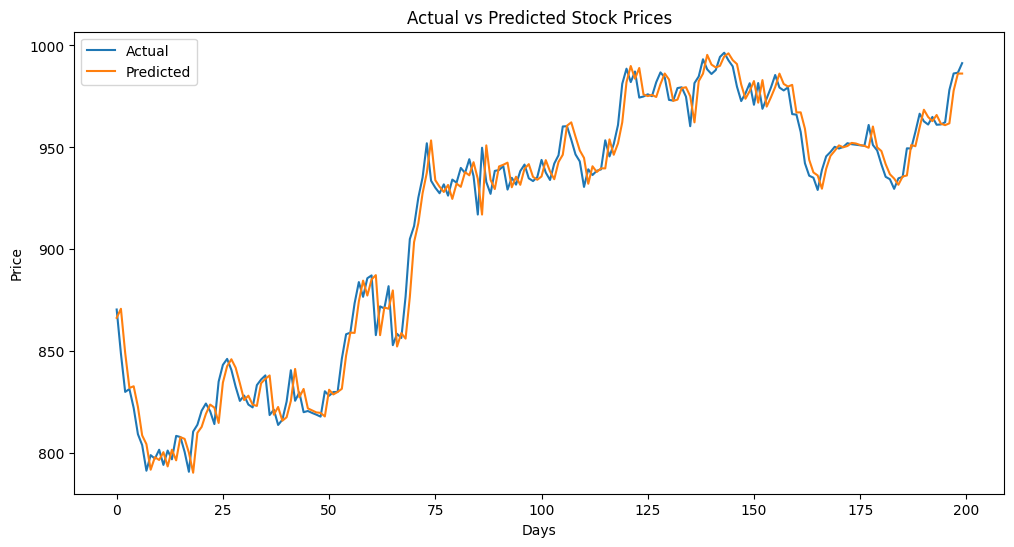

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    y_pred[:200],
    label='Predicted'
)

plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

plt.show()

# Step 4:-Random Forest Regressor

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [38]:
rf_pred = rf.predict(X_test)

rf_pred[:5]

array([868.76564819, 867.57704163, 852.35924133, 840.66690186,
       833.81521118])

In [39]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² :", rf_r2)

MAE : 215.3310907213054
RMSE: 780.3038962400827
R² : 0.9728432939071427


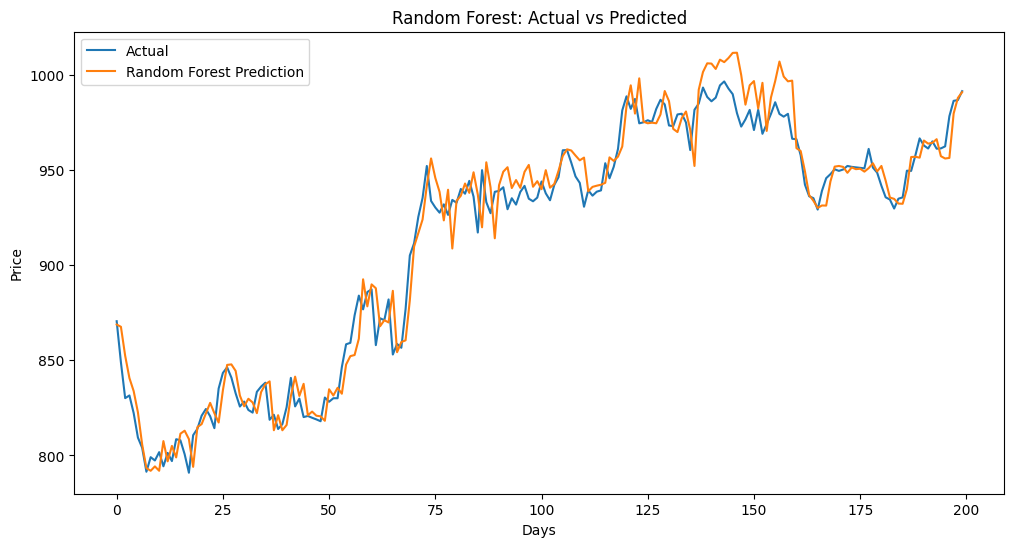

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    rf_pred[:200],
    label='Random Forest Prediction'
)

plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

plt.show()

In [45]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
3,Close,0.828521
2,Low,0.060628
7,MA_7,0.039200
1,High,0.034412
0,Open,0.019523
10,Lag_1,0.009580
8,MA_21,0.007456
9,MA_50,0.000182
11,Lag_5,0.000069
18,Price_vs_MA50,0.000066


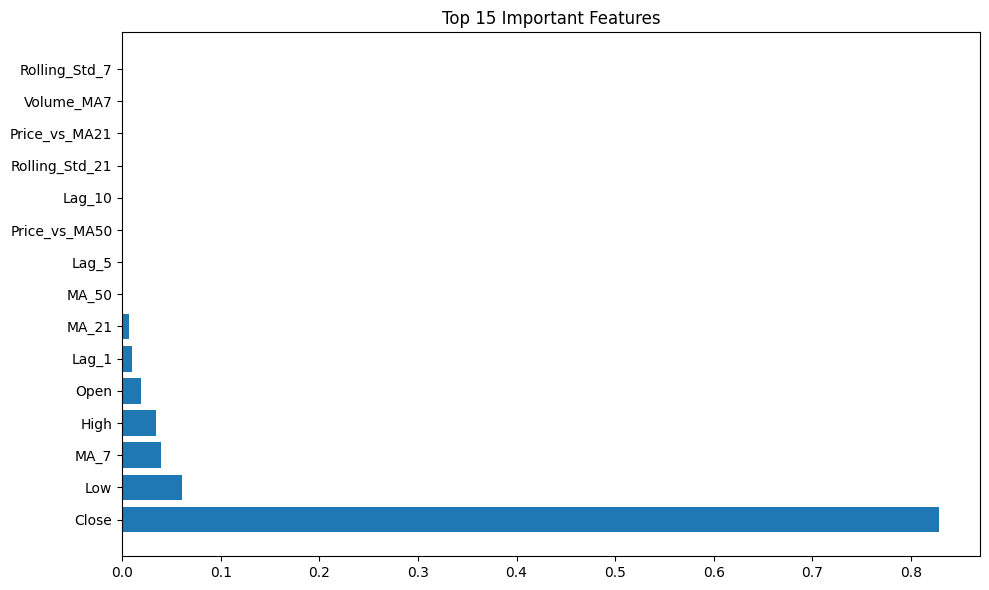

In [46]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'][:15],
    importance_df['Importance'][:15]
)

plt.title("Top 15 Important Features")
plt.tight_layout()
plt.show()

# Step 5:xgBoost Regressor

In [47]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [48]:
xgb_pred = xgb.predict(X_test)

xgb_pred[:5]

array([861.0661 , 871.2972 , 844.9973 , 835.3805 , 837.25726],
      dtype=float32)

In [49]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = mean_squared_error(
    y_test,
    xgb_pred
) ** 0.5

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R² :", xgb_r2)

MAE : 227.98753894388918
RMSE: 830.5853270945256
R² : 0.9692306692214888


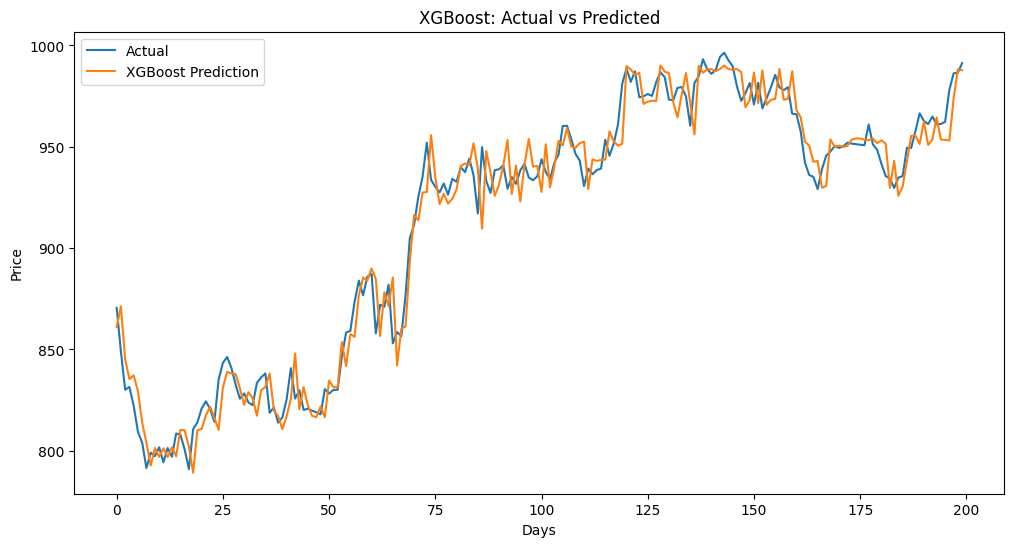

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    xgb_pred[:200],
    label='XGBoost Prediction'
)

plt.title('XGBoost: Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

plt.show()

In [52]:
importance_df_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

importance_df_xgb = importance_df_xgb.sort_values(
    by='Importance',
    ascending=False
)

importance_df_xgb

,Feature,Importance
10,Lag_1,0.411962
3,Close,0.302183
7,MA_7,0.176675
2,Low,0.055944
8,MA_21,0.023594
1,High,0.017153
9,MA_50,0.005848
19,Rolling_Std_7,0.002779
0,Open,0.002734
12,Lag_10,0.000557


# Step 6-Model Comparision

In [53]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        mae,
        rf_mae,
        xgb_mae
    ],
    'RMSE': [
        rmse,
        rf_rmse,
        xgb_rmse
    ],
    'R2': [
        r2,
        rf_r2,
        xgb_r2
    ]
})

comparison.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear Regression,27.887534,70.941665,0.999776
1,Random Forest,215.331091,780.303896,0.972843
2,XGBoost,227.987539,830.585327,0.969231


Best Model:Linear Regression

In [55]:
print(X_train.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Volume_MA7', 'Volume_Ratio',
       'MA_7', 'MA_21', 'MA_50', 'Lag_1', 'Lag_5', 'Lag_10', 'Daily_Return',
       'Momentum_5', 'Momentum_21', 'Price_vs_MA7', 'Price_vs_MA21',
       'Price_vs_MA50', 'Rolling_Std_7', 'Rolling_Std_21', 'Vol_Ratio',
       'Range_Pct', 'Open_Close_Pct'],
      dtype='object')


In [56]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

feature_importance

,Feature,Coefficient
23,Open_Close_Pct,-1.326333e+02
16,Price_vs_MA7,-1.298675e+02
13,Daily_Return,1.114704e+02
14,Momentum_5,9.006677e+01
22,Range_Pct,6.065092e+01
15,Momentum_21,2.642464e+01
17,Price_vs_MA21,-1.890585e+01
18,Price_vs_MA50,-1.340445e+01
21,Vol_Ratio,1.838143e+00
3,Close,1.073919e+00


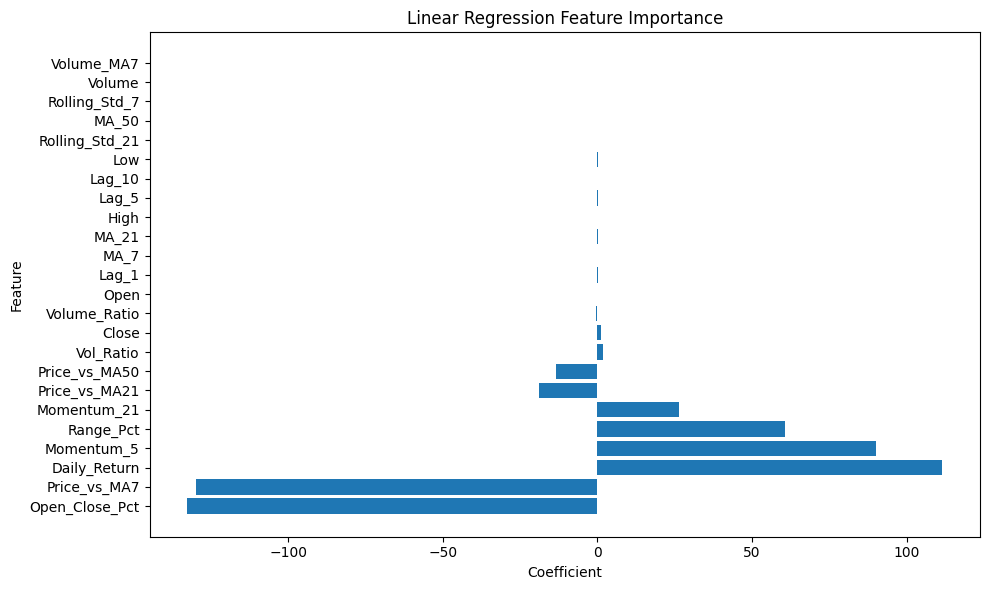

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Coefficient']
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [58]:
import os

print(os.getcwd())

C:\Users\USER\Documents\PROJECTS\stock risk dashboard\notebooks


In [59]:
print(os.listdir(".."))

['.gitignore', '.ipynb_checkpoints', '07_streamlit_app.py', 'dashboard', 'data', 'notebooks', 'outputs', 'README.md', 'requirements.txt', 'src']


In [60]:
import joblib

joblib.dump(
    lr,
    "../outputs/models/best_stock_prediction_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
